<h1 style="font-size: 36px; color: blue;">STOWA Proevenverzameling tool v5.0</h1>

Deze Jupyter notebook bevat functies opgenomen in de python package PV-tooling ### voor het opstellen van lokale of regionale proevenverzamelingen voor het bepalen van geotechnische parameters. De methode is ontwikkeld voor het uitvoeren van analyses in relatie tot de geotechnische stabiliteit van dijken, maar kan ook breder worden toegepast. De notebook dient tevens als handleiding om de gebruiker stapsgewijs te ondersteunen bij het opstellen van een proevenverzameling.

Met de beschikbare functies kunnen zowel gedraineerde als ongedraineerde sterkteparameters worden berekend alsmede enkele samendrukkingsparameters. Van deze parameters worden verwachtingswaarde, karakteristieke waarde en rekenwaarde bepaald. 

De functies zijn opgesteld conform de werkwijze beschreven in [Statistische methoden t.b.v. proevenverzamelingen, DIV, v1.0], zie tevens: https://publicwiki.deltares.nl/spaces/HWBPMacro/pages/217120830/Sterkte+van+grond#Sterktevangrond-150.
De tool bevat tevens hulpmiddelen voor het onderscheiden of samenvoegen van groepen in een verzameling op basis van verschillende kenmerken. 

De onderliggende data om een proevenverzameling samen te stellen is beschreven in een vaste structuur. Deze structuur is vastgelegd in een uitwisselformat. Het uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx. De geotechnische laboratoria kennen deze database en kunnen deze database vullen met resultaten van grond- en laboratoriumonderzoek. Op deze wijze ontstaat er uniformering op het gebied van data-uitwisseling en –opslag van proefresultaten.

NB. De verantwoordelijkheid voor het gebruik van deze tools ligt bij de gebruiker.


In [21]:
# Importeren van benodigde packages

import importlib.util

# Functie om te controleren of een package is geïnstalleerd
def check_package_install(package_name):
    package_spec = importlib.util.find_spec(package_name)
    if package_spec is None:
        print(f"{package_name} is niet geïnstalleerd. Installatie wordt gestart...")
        !pip install {package_name}
    else:
        print(f"{package_name} is al geïnstalleerd.")

# Controleer en installeer indien nodig
check_package_install("openpyxl")
check_package_install("ipyfilechooser")
check_package_install("pandas_schema")
check_package_install("xlsxwriter")
check_package_install("ipywidgets")

#jupyter nbextension enable --py widgetsnbextension


#!pip uninstall C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.0-py3-none-any.whl
#!pip install --force-reinstall C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.2-py3-none-any.whl

!pip install C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl


openpyxl is al geïnstalleerd.
ipyfilechooser is al geïnstalleerd.
pandas_schema is al geïnstalleerd.
xlsxwriter is al geïnstalleerd.
ipywidgets is al geïnstalleerd.
Defaulting to user installation because normal site-packages is not writeable
Processing c:\python_cursus\pvtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl
pv-tool is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


## Stap 1: Inladen van benodigde data

De benodigde data voor het bepalen van geotechnische parameters kan op 3 manieren worden ingeladen in deze notebook.
- Op basis van de data in de excel versie van de proevenverzamelingtool (vanaf versie 4.2n of hoger) waarin zowel reeds proevenverzamelingen zijn onderscheiden als geotechnische parameters zijn vastgesteld. NB. de onderscheiden verzamelingen worden als uitgangspunt worden ingeladen, de sterkteparameters worden opnieuw berekend. Onderliggende keuzes zoals het gewenste rekpercentage en de gekozen raaklijnen worden niet ingelezen uit de Excelversie. 
- Op basis van het Excel Uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx waarin nog geen verzamelingen onderscheiden zijn.

Zie tevens: https://github.com/kkpdata/Proevenverzamelingentool/

De proevenverzamelingtool of het uitwisselformat worden omgezet naar het template proevenverzamelingtool 5.0 

- Op basis van het Excel template voor de Proevenverzameling 5.0. Deze bestaat uit de data conform het uitwisselformat 4.2 aangevuld met de benodigde in en uitvoerdata van voorliggende tooling.


In [1]:
# Laden van widgets voor uploaden bestanden
import ipywidgets as widgets
from IPython.display import display, Markdown
from ipyfilechooser import FileChooser


# Dropdown widget voor keuze template
dropdown_template = widgets.Dropdown(
    options=[
        'Proevenverzamelingtool 4.2n of hoger', 
        'STOWA uitwisselingsformat 4.2x', 
        'Proevenverzamelingtool 5.0'
    ],  # De opties in het menu
    value='Proevenverzamelingtool 5.0',  # Standaard geselecteerde waarde
    description='Template:',
    disabled=False, 
    layout=widgets.Layout(width='400px') 
)


# filter_pattern="*.xlsm",  # Filter voor alleen .xlsm bestanden


# Maak een FileChooser-widget
file_chooser_import = FileChooser(
    '/',
    title="Selecteer een bestand om te uploaden",
    show_hidden=False  # Verberg verborgen bestanden
)

#Titel
display(Markdown("**Stap 1: Kies Excel template voor uploaden data:**"))

# Toon de dropdown widget keuze template
display(dropdown_template)

# Toon widget voor keuze uploaden bestand
display(file_chooser_import)

print()

**Stap 1: Kies Excel template voor uploaden data:**

Dropdown(description='Template:', index=2, layout=Layout(width='400px'), options=('Proevenverzamelingtool 4.2n…

FileChooser(path='C:\', filename='', title='Selecteer een bestand om te uploaden', show_hidden=False, select_d…

## Stap 2: Importeren en valideren data

De validatie bestaat uit de volgende controles: voor de verschillende typen proeven – classificatie, CRS-proef, samendrukkingsproef, DSS-proef en triaxiaalproef – wordt per regel gecontroleerd of er een proef is uitgevoerd (data ingevuld) en zo ja, of de velden die in de PV-tool benodigd zijn volledig en correct zijn ingevuld.

Het resultaat van de validatie wordt opgeslagen in een Excel-bestand, waarin per gevalideerde kolom en regel het resultaat wordt weergegeven. Daarnaast wordt per kolom aangegeven hoeveel fouten zijn aangetroffen. Ook wordt vermeld of een bepaalde kolom noodzakelijk is voor de functionaliteit van de tooling of dat de tooling ook zonder die kolom kan worden uitgevoerd.

In [4]:
from pv_tool.imports.import_data import Dbase
from pathlib import Path
dbase = Dbase()

# Controleer dropdown template en geef de gekozen waarde terug
if dropdown_template.value:
    print(f'Je hebt gekozen: {dropdown_template.value}')
else:
    print("Er is geen template geselecteerd.")

# bepaal source voor template
template_mapping = {
    "Proevenverzamelingtool 4.2n of hoger" : "PV-tool",
    "STOWA uitwisselingsformat 4.2x" : "Stowa",
    "Proevenverzamelingtool 5.0" : "Dbase"
}
template_code = template_mapping.get(dropdown_template.value, "Onbekend template")
print(f"Code in script: {template_code}")

# Controleer of een bestand is geselecteerd
if file_chooser_import.selected:
    # Verkrijg het volledige pad van het geselecteerde bestand
    full_path = file_chooser_import.selected
    # Verkrijg de directory en bestandsnaam
    selected_directory = file_chooser_import.selected_path
    filename = file_chooser_import.selected_filename

    # Print de resultaten
    print(f"Geselecteerd bestand: {filename}")
    print(f"Geselecteerde directory: {selected_directory}")
    print(f"Volledig pad: {full_path}")
else:
    print("Er is geen bestand geselecteerd. Selecteer een bestand voordat je verder gaat.")


#C:\python_cursus\PVtool2025_github\import\SAFE_PVTOOL.xlsm

#import dir en bestandsnaam en export directory
dir_in = (file_chooser_import.selected)
dir2 = Path(file_chooser_import.selected_path)

#starten importeren en valideren
#dbase.import_data_and_validate(source='PV-tool', source_dir=dir_in, export_path=dir2)
dbase.import_data_and_validate(source = template_code, source_dir=dir_in, export_path=dir2)

#export template
dbase.export_dbase_to_excel(export_dir=dir2)

Je hebt gekozen: STOWA uitwisselingsformat 4.2x
Code in script: Stowa
Geselecteerd bestand: 23ZP0747_STOWA-definitief.xlsx
Geselecteerde directory: C:\python_cursus\PVtool2025_github\import
Volledig pad: C:\python_cursus\PVtool2025_github\import\23ZP0747_STOWA-definitief.xlsx
Excel-bestand geëxporteerd naar: C:\python_cursus\PVtool2025_github\import\Dbase-template.xlsx


## Stap 3: Aanvullen benodigde input voor afleiden parameters

Aanvullend op de proefdata is voor het afleiden van de ongedraineerde schuifsterkteparameters specifieke informatie benodigd bij de beschikbare DSS- en triaxiaalproeven in de PV-tool. Deze data wordt automatisch toegevoegd aan het template voor de proevenverzamelingtool 5.0 indien de validatie goed doorlopen is, maar moet door de gebruiker op een aantal punten nog wel worden gecontroleerd. 

- Betreft het een OC of NC proef, oftewel is de proef geconsolideerd bij de geschatte dagelijkse effectieve terreinspanning (OCR>1) of (ruim) boven de grensspanning (OCR=1). De tooling doet hier een voorstel voor door de consolidatiespanning (sigma'vc) te vergelijken met de terreinspanning (sigma'vi). Indien deze niet meer dan +30% afwijkt wordt aangenomen dat het een OC-proef betreft en bij grotere afwijkingen een NC-proef. Het is noodzakelijk om dit voorstel te controleren. In de regel is een OC-proef vrijwel altijd dicht bij de terreinspanning gekozen en ligt een NC-proef er ruim boven, maar hier zijn altijd uitzonderingen op mogelijk. Deze data wordt weggeschreven in de velden (ANA_TXT_CONSOLIDATIE_TYPE_VOORSTEL) en ANA_DSS_CONSOLIDATIE_TYPE_VOORSTEL). Het voorstel kan handmatig overschreven worden in de kolom (ANA_TXT_CONSOLIDATIE_TYPE_HANDMATIG) en (ANA_DSS_CONSOLIDATIE_TYPE_HANDMATIG)
  
- Betreft het een OC-proef dan is er een waarde benodigd van de overconsolidatieratio, oftwel OCR van het monster bij het afleiden van de Shansep parameters op basis van de methode "Lineaire regressie: bepaling S en m uit triaxiaal- of DSS proeven". OCR = grensspanning (sigma'vy) / vertikale consolidatiespanning (sigma'vc). De PV-tool vereist hiervoor per monster een schatting van schatting van de grensspanning. Indien er bij dezelfde bus een resultaat beschikbaar is uit een samendrukkingsproef of CRS-proef wordt deze gebruikt. Indien deze ontbreekt wordt een voorstel gedaan op basis van de gemiddelde POP (POP = grensspanning - effectieve terreinspanning o.b.v. de monsters waar wel een proef is uitgevoerd ) per boring. Indien er bij de betreffende boring geen grensspanning beschikbaar is wordt waarde Error ingevuld. Het is dan niet mogelijk om geautomatiseerd een OCR te schatten. Deze data wordt weggeschreven in de velden (ANA_GRENSSPANNING_VOORSTEL). Het is noodzakelijk om de voorgestelde waarden te controleren. Als gebruiker kan je het voorstel overrulen in de kolom (ANA_GRENSSPANNING_HANDMATIG).

NB. Bij gebruik van de bestaande Excel versie van de proevenverzamelingtool zijn de cellen ANA_GRENSSPANNING_HANDMATIG veelal reeds ingevuld. In dat geval worden deze waarden overgenomen. 

- de verzameling waartoe een uitgevoerde proef behoort wordt overgenomen wanneer een bestaande excel proevenverzamelingtool wordt ingeladen en weggeschreven in het veld (PV_NAAM). Als er geen waarde beschikbaar is wordt de naam "TXT-proef" of "DSS-proef" ingevuld. De gebruiker kan hier naar eigen inzicht grondlagen in onderscheiden. Dit kan door dit handmatig op te geven in het template of met behulp van de functies om groepen te onderscheiden. Per onderscheiden verzameling kunnen in stap 4 parameters worden afgeleid. 


In [30]:
#run aanvullen benodigde input.

#ALG__BORING_MONSTERNR_ID berekenen conform functie die reeds door Tjalda is gemaakt.

#aanvullend op de data worden de volgende kolommen toegevoegd
#als ALG__DSS = true 
#of als ALG__TRIAXIAAL = true 
#dan gaan we deze cellen ook vullen.

#ANA_TERREINSPANNING	(conform ANA functie die reeds door Tjalda is gemaakt)
#ANA_TXT_CONSOLIDATIE_TYPE_VOORSTEL, als ANA_DSS_MAX_CONSOLIDATIE_SPANNING niet meer dan +30% afwijkt van [ANA_TERREINSPANNING] dan OC, anders NC
#ANA_TXT_CONSOLIDATIE_TYPE_HANDMATIG, leeg laten, gebruiker kan hier in template automatisch bepaalde waarde overrulen.
#ANA_DSS_CONSOLIDATIE_TYPE_VOORSTEL als ANA_TXT_MAX_CONSOLIDATIE_SPANNING niet meer dan +30% afwijkt van [ANA_TERREINSPANNING] dan OC, anders NC
#ANA_DSS_CONSOLIDATIE_TYPE_HANDMATIG, leeg laten, gebruiker kan hier in template automatisch bepaalde waarde overrulen.


#ANA_GRENSSPANNING_PROEF (conform ANA_GRENSSPANNING die reeds door Tjalda is gemaakt)

#volgende alleen voor OC proeven!
#ANA_GRENSSPANNING_VOORSTEL (deze is nieuw, op basis van de functies reeds door Tjalda gemaakt ANA_POP_VELD	en ANA_POP_VELD_GEMIDDELD 
#doen we een voorstel voor de grensspanning als een proefwaarde ontbreekt. 
#Als er bij de betreffende boring geen grensspanning beschikbaar is wordt waarde Error ingevuld.

#ANA_GRENSSPANNING_HANDMATIG (bij het inladen van de bestaande PVtool wordt deze waarde overgenomen, bij het uitwisselformat is deze leeg en mag de gebruiker deze invullen) 
#ANA_GRENSSPANNING_REKEN (deze pakt de te hanteren waarde, handmatig is leidend, dan voorstel of proef, als er wel een proef is en geen grensspanning dan error weergeven)

#ANA_OCR_TXT_MONSTER deze kan berekend worden door de grensspanning te delen door ANA_TERREINSPANNING bij de OC proeven, bij NC proeven is waarde 1.
#ANA_OCR_DSS_MONSTER deze kan berekend worden door de grensspanning te delen door ANA_TERREINSPANNING bij de OC proeven, bij NC proeven is waarde 1.


#PV_NAAM (bij het inladen van de bestaande PVtool wordt deze waarde overgenomen, anders bij TXT proef default "TXT-proef" invullen en "DSS-proef" bij DSS.
#PV_OPMERKING (bij het inladen van de bestaande PVtool wordt deze waarde overgenomen, anders leeg)

#deze kolommen vormen samen met de data het template voor de PV tool. hier een dataframe van maken voor export en om verder te gaan in stap 4.

df =                                PV_NAAM      S'      T         s_tt  \
ALG__BORING_MONSTERNR_ID                                             
8.0_bo_36-5_1002+002_kr_9a   TXT-proef   82.85  52.56    72.996681   
16.0_bo_36-5_964+006_kr_5    TXT-proef  103.60  49.99   858.127276   
22.0_bo_36-5_964+006_kr_10   TXT-proef   98.59  50.70   589.703405   
31.0_bo_36-5_969+001_kr_3    TXT-proef   39.08  20.96  1240.884495   
35.0_bo_36-5_969+001_kr_7    TXT-proef   79.73  48.18    29.417710   
48.0_bo_36-5_972+100_kr_13   TXT-proef   36.52  24.11  1427.796191   
55.0_bo_36-5_972+100_kr_7    TXT-proef   97.00  36.72   515.008991   
60.0_bo_36-5_978+101_kr_3    TXT-proef   47.50  20.93   718.571848   
66.0_bo_36-5_978+101_kr_9    TXT-proef   79.35  44.17    25.440015   
77.0_bo_36-5_983+001_kr_7    TXT-proef   94.80  53.44   419.996229   
85.0_bo_36-5_987+094_bit_4   TXT-proef   58.99  36.29   234.585691   
86.0_bo_36-5_987+094_bit_5   TXT-proef   43.78  23.90   931.848305   
87.0_bo_36-5_98

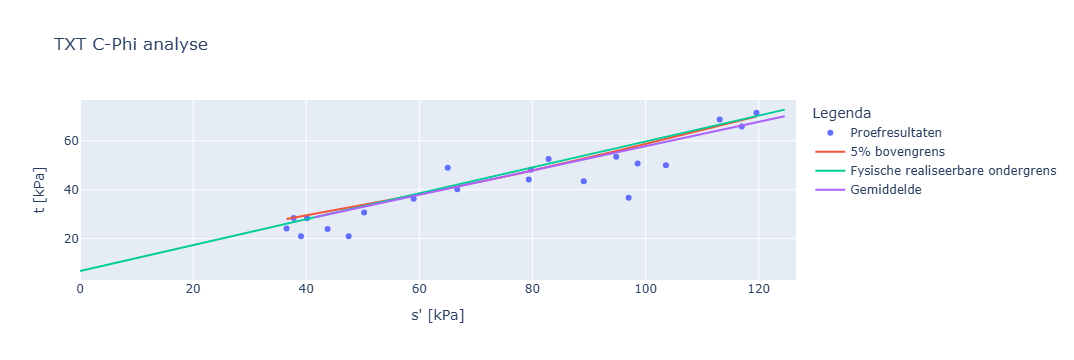

In [67]:
# test c phi analyse direct starten zonder widgets ed

from pv_tool.analysis.c_phi_analysis import CPhiAnalyse
from pv_tool.analysis.variables import *

dbase_df = dbase.dbase_df
#print(dbase_df.index)



#analyse = CPhiAnalyse(dbase=dbase, investigation_groups=['TXT_SAFE_klei_licht_16_175'], effective_stress='15% rek',
#                      analysis_type='TXT_CPhi')

analyse = CPhiAnalyse(dbase=dbase, investigation_groups=['TXT-proef'], effective_stress='15% rek',
                      analysis_type='TXT_CPhi')


analyse.apply_parameters(cohesie_gem = 8)
analyse.apply_parameters(phi_kar = 0.53)
analyse.apply_parameters(cohesie_kar = 6.72)

analyse.apply_settings(material_factor_cohesion = 1) 
analyse.apply_settings(material_factor_tan_phi = 1) 

#analyse.apply_settings(alpha = Alpha.LOCAL) 

analyse.factsheet()
analyse.show_figure()


# Bestandspad samenstellen: gekozen map + bestandsnaam
bestand_naam = f"{selected_directory}/c_phi_data_geforceerd.xlsx"
# Dataframe tussenstappen
df = analyse.cphi_analyses_data_df

# Exporteer DataFrame naar Excel
df.to_excel(bestand_naam, index=False)


In [ ]:
print(analyse.phi_kar_handmatig)
#print(analyse.helling_gecor)

print(analyse.cohesie_gem_handmatig)

print(analyse.tan_phi_kar)

tan(phi)_gem =  33.502150297819306
c_gem =  9.593877869367985
#tan(phi)_gem en c_gem gaan beide nog mis bij een handmatig opgegeven waarde van cohesie gemiddeld (a1).
#dat komt omdat phi gemiddeld (a2) nu niet opnieuw wordt berekend op basis van de handmatig opgegeven gemiddelde cohesie gemiddeld (a1).




## Stap 4a: Bepalen gedraineerde parameters triaxiaalproeven op basis van fit (C en Phi)

In deze stap worden op basis van de data vastgelegd in het template PV-tool 5.0. gedraineerde parameters bepaald. Maak  een keuze uit de verzameling waarop de statistische analyse moet plaatsvinden. Als er nog geen aparte verzamelingen onderscheiden zijn in het veld (PV_NAAM) worden alle triaxaalproeven in één verzameling opgenomen. 

Als gebruiker kunnen handmatig verzamelingen worden opgegeven in de Excel template in het veld PV_NAAM of er kan gebruik worden gemaakt van de functie:
Definiëren en aanpassen van verzamelingen (stap #). Met behulp van de functie ## kunnen in de grafiek met behulp van de selectietool (should have) ook één of meer proefresultaten worden geselecteerd en worden toegekend aan een andere groep.

Geef  het te hanteren rekpercentage op waarbij de s' en t zijn bepaald: 2%, 5%, 15%, eindrek of bij pieksterkte. 
Indien er eerder parameters zijn vastgesteld worden de gemaakte keuzes voor het % en de raaklijnen ingeladen.

Ook kunnen meerdere verzamelingen getoond worden.

In [8]:
# Laden van widgets voor keuzes afleiden gedraineerde parameters
import ipywidgets as widgets
from IPython.display import display, Markdown

dbase_df = dbase.dbase_df

#### Inlezen lijst met unieke namen in PV_NAAM

# Filter het dataframe waar ALG__TRIAXIAAL True is
filtered_df = dbase_df[dbase_df['ALG__TRIAXIAAL'] == True]
# Selecteer de kolom PV_NAAM en haal unieke waarden op
unique_names = filtered_df['PV_NAAM'].unique()
# Converteer naar een lijst
unique_names_list = unique_names.tolist()


#### Widgets definieren 

# Dropdown widget voor rek%
dropdown_rekpercentage = widgets.Dropdown(
    options=[
        '2% rek', 
        '5% rek',
        '15% rek',
        'eindsterkte',
        'pieksterkte',
    ],  # De opties in het menu
    value='eindsterkte',  # Standaard geselecteerde waarde
    disabled=False, 
    layout=widgets.Layout(width='400px')  # Stel de breedte van de widget in
)

import ipywidgets as widgets

# Dropdown widget met unieke namen uit het dataframe
dropdown_verzameling_txt = widgets.Dropdown(
    options=unique_names_list,  # Gebruik de lijst met unieke namen als opties
    value=unique_names_list[0] if unique_names_list else None,  # Standaard geselecteerde waarde
    disabled=False, 
    layout=widgets.Layout(width='400px')  # Stel de breedte van de widget in
)

#### WIDGETS TONEN

# Toon de dropdown widget verzameling
display(Markdown("**Kies verzameling voor statistische analyse:**"))
display(dropdown_verzameling_txt)

# Titel keuze proevenverzameling vergelijken
#display(Markdown("**Kies verzameling ter vergelijking:**"))
print()
# hoe / wat kunnen we doen om keuze voor meerdere verzamelingen op te nemen?

# Toon de dropdown widget rekpercentage
display(Markdown("**Kies rekpercentage s'en t:**"))
display(dropdown_rekpercentage)

print()

**Kies verzameling voor statistische analyse:**

Dropdown(layout=Layout(width='400px'), options=('TXT-proef',), value='TXT-proef')

**Kies rekpercentage s'en t:**

Dropdown(index=3, layout=Layout(width='400px'), options=('2% rek', '5% rek', '15% rek', 'eindsterkte', 'piekst…

Je hebt gekozen: TXT-proef
Je hebt gekozen: 15% rek


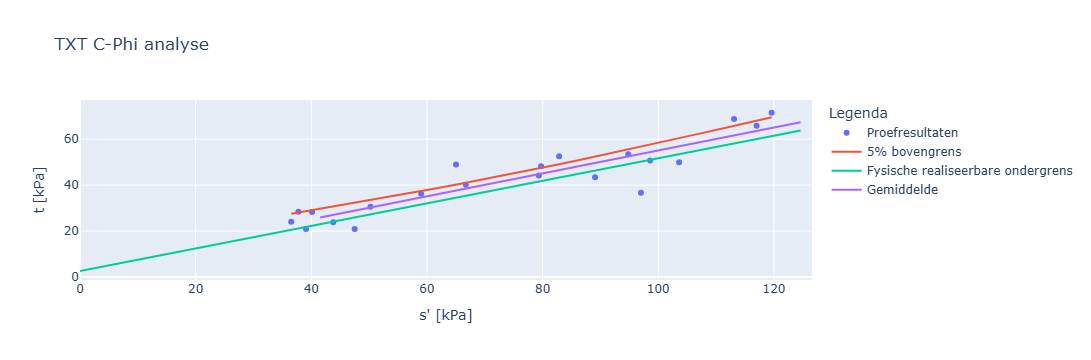

In [13]:
# test c phi analyse
from pv_tool.analysis.c_phi_analysis import CPhiAnalyse
from pv_tool.analysis.variables import *

dbase_df = dbase.dbase_df
#print(dbase_df.index)

# Controleer dropdown keuze verzameling
if dropdown_verzameling_txt.value:
    print(f'Je hebt gekozen: {dropdown_verzameling_txt.value}')
else:
    print("Er is geen verzameling geselecteerd.")

# Controleer dropdown templates en geef de gekozen waarde terug
if dropdown_rekpercentage.value:
    print(f'Je hebt gekozen: {dropdown_rekpercentage.value}')
else:
    print("Er is geen template geselecteerd.")


#analyse = CPhiAnalyse(dbase=dbase, investigation_groups=['TXT_SAFE_klei_licht_16_175'], effective_stress='15% rek',
#                      analysis_type='TXT_CPhi')
analyse = CPhiAnalyse(dbase=dbase, investigation_groups=[dropdown_verzameling_txt.value], effective_stress= dropdown_rekpercentage.value,
                      analysis_type='TXT_CPhi')


#analyse.apply_parameters(cohesie_gem = 8)
#analyse.apply_parameters(phi_kar = 0.53)
#analyse.apply_parameters(cohesie_kar = 6.72)

#analyse.apply_settings(material_factor_cohesion = 1) 
#analyse.apply_settings(material_factor_tan_phi = 1) 

#analyse.apply_settings(alpha = Alpha.LOCAL) 

#analyse.factsheet()
analyse.show_figure()

# Bestandspad samenstellen: gekozen map + bestandsnaam
bestand_naam = f"{selected_directory}/c_phi_data_geforceerd.xlsx"
# Dataframe tussenstappen
df = analyse.cphi_analyses_data_df

# Exporteer DataFrame naar Excel
df.to_excel(bestand_naam, index=False)




In [12]:

import ipywidgets as widgets
from IPython.display import display, Markdown

# Dummy waarden kolom 2, deze moeten straks worden ingevuld uit de berekening.

#analyse.apply_parameters(cohesie_gem = 8)
#analyse.apply_parameters(phi_kar = 0.53)
#analyse.apply_parameters(cohesie_kar = 6.72)

phi_gemiddeld_benadering = 0.55
cohesie_gemiddeld_benadering = 4.0
phi_karakteristiek_benadering = 0.54
cohesie_karakteristiek_benadering = 1.0

# Dummy variabelen kolom 3 voor de uiteindelijke output, deze worden weergegeven in de derde kolom.
# Deze parameters moeten worden ingelezen uit de resultaten tabel
PV_A1_COH_GEM = 5
PV_A2_PHI_KAR = 0.53
PV_A1_COH_KAR = 2
PV_PARTPHI = 1
PV_PARTCOH = 1
PV_TYPEVERZAMELING = 0.75

# Maak een raster van 8 rijen en 3 kolommen (7 data rijen + 1 header rij)
grid = widgets.GridspecLayout(8, 3)

# Vul de eerste rij met veldnamen
grid[0, 0] = widgets.Label('Beschrijving')
grid[0, 1] = widgets.Label('Benadering')
grid[0, 2] = widgets.Label('Invoer')

# Beschrijvingen voor de eerste kolom
descriptions = [
    'a2gem (phi gemiddeld)',
    'a1gem =snijpunt y-as (cohesie gemiddeld)',
    'a2kar (phi karakteristiek)',
    'a1kar =snijpunt y-as (cohesie karakteristiek)',
    'partiele materiaalfactor tan phi [-]',
    'partiele materiaalfactor cohesie [-]',
    'type verzameling: lokaal = 1,0; regionaal = 0,75',
]

# Benaderingen op basis van regressie
benadering_values = [
    phi_gemiddeld_benadering,
    cohesie_gemiddeld_benadering,
    phi_karakteristiek_benadering,
    cohesie_karakteristiek_benadering,
    '-',  # Geen benadering voor partiele materiaalfactor tan phi
    '-',  # Geen benadering voor partiele materiaalfactor cohesie
    '-',  # Geen benadering voor type verzameling
]

# Waarden voor de derde kolom
invoer_values = [
    None,  # Eerste rij is niet invulbaar
    PV_A1_COH_GEM,  # Tweede rij
    PV_A2_PHI_KAR,  # Derde rij
    PV_A1_COH_KAR,  # Vierde rij
    PV_PARTPHI,  # Vijfde rij
    PV_PARTCOH,  # Zesde rij
    PV_TYPEVERZAMELING,  # Zevende rij
]

# Functie om wijzigingen in kolom 3 op te slaan
def on_value_change(change, row):
    global PV_A1_COH_GEM, PV_A2_PHI_KAR, PV_A1_COH_KAR, PV_PARTPHI, PV_PARTCOH, PV_TYPEVERZAMELING
    new_value = change['new']
    if row == 1:  # Tweede rij
        PV_A1_COH_GEM = new_value
    elif row == 2:  # Derde rij
        PV_A2_PHI_KAR = new_value
    elif row == 3:  # Vierde rij
        PV_A1_COH_KAR = new_value
    elif row == 4:  # Vijfde rij
        PV_PARTPHI = new_value
    elif row == 5:  # Zesde rij
        PV_PARTCOH = new_value
    elif row == 6:  # Zevende rij
        PV_TYPEVERZAMELING = new_value

# Vul de tabel
for i, (desc, benadering, invoer) in enumerate(zip(descriptions, benadering_values, invoer_values), start=0):
    grid[i+1, 0] = widgets.Label(desc)  # Beschrijving in de eerste kolom
    grid[i+1, 1] = widgets.Label(str(benadering))  # Waarde in de tweede kolom, met '-' indien geen benadering
    
    if i == 0:  # Eerste rij in de derde kolom is niet invulbaar
        grid[i+1, 2] = widgets.Label('-')
    else:
        input_widget = widgets.FloatText(value=invoer)  # Waarde in de derde kolom
        grid[i+1, 2] = input_widget
        input_widget.observe(lambda change, row=i: on_value_change(change, row), names='value')

# Toon de tabelwidget
display(Markdown("**Opgeven parameters effectieve schuifsterkteparameters (fit):**"))
display(grid)



**Opgeven parameters effectieve schuifsterkteparameters (fit):**

GridspecLayout(children=(Label(value='Beschrijving', layout=Layout(grid_area='widget001')), Label(value='Benad…

In [11]:
#gewijzigde input voor fit.

print(f"PV_A1_COH_GEM: {PV_A1_COH_GEM}")
print(f"PV_A2_PHI_KAR: {PV_A2_PHI_KAR}")
print(f"PV_A1_COH_KAR: {PV_A1_COH_KAR}")
print(f"PV_PARTPHI: {PV_PARTPHI}")
print(f"PV_PARTCOH: {PV_PARTCOH}")
print(f"PV_TYPEVERZAMELING: {PV_TYPEVERZAMELING}")

PV_A1_COH_GEM: 5
PV_A2_PHI_KAR: 0.53
PV_A1_COH_KAR: 2
PV_PARTPHI: 1
PV_PARTCOH: 1
PV_TYPEVERZAMELING: 0.75


### Resultaten analyse Triaxiaalproeven single stage (TXT) resultaten - Sigma - Tau diagram

s' - t op basis van: eindrek


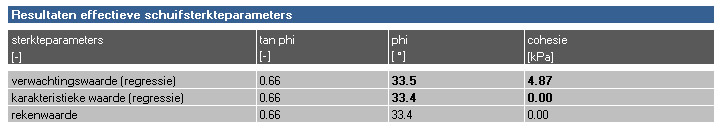

en nog regel met berekende standaarddeviaties D-stab

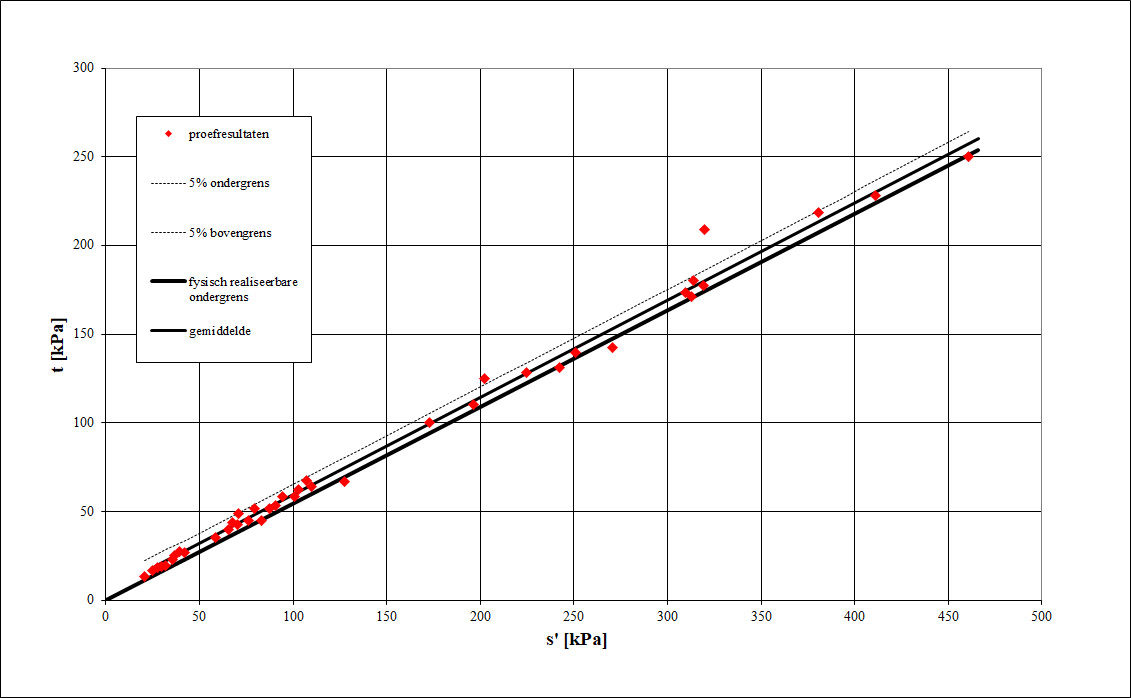





















## Stap 4b: Bepalen gedraineerde parameters triaxiaalproeven methode SH macrostabiliteit (Phi)

## Stap 5a: Bepalen ongedraineerde parameters triaxiaal- of DSS proeven (S, m en POP)



In [2]:
# Laden van widgets voor keuzes afleiden ongedraineerde parameters S, m en POP 
import ipywidgets as widgets
from IPython.display import display, Markdown

#### Widgets definieren 

# Dropdown widget voor rek%
dropdown_rekpercentage = widgets.Dropdown(
    options=[
        '2% rek', 
        '5% rek',
        '15% rek',
        '20% rek',
        'eindrek',
        'pieksterkte',
    ],  # De opties in het menu
    value='eindrek',  # Standaard geselecteerde waarde
    disabled=False, 
    layout=widgets.Layout(width='400px')  # Stel de breedte van de widget in
)

# Dropdown widget voor proevenverzameling op basis van triaxiaalproeven
dropdown_verzameling_txt = widgets.Dropdown(
    options=[
        'TXT-proef', 
        'test 1',
    ],  # De opties in het menu moeten op basis van een lijst worden gegenereerd uit veld PV_NAAM
    value='TXT-proef',  # Standaard geselecteerde waarde
    disabled=False, 
    layout=widgets.Layout(width='400px')  # Stel de breedte van de widget in
)


#### WIDGETS TONEN

# Toon de dropdown widget verzameling
display(Markdown("**Kies verzameling voor statistische analyse:**"))
display(dropdown_verzameling_txt)

# Titel keuze proevenverzameling vergelijken
print()
display(Markdown("**Kies verzameling ter vergelijking:**"))
print()
# hoe / wat kunnen we doen om keuze voor meerdere verzamelingen op te nemen?

# Toon de dropdown widget rekpercentage
display(Markdown("**Kies rekpercentage Su:**"))
display(dropdown_rekpercentage)


print()
print()

**Kies verzameling voor statistische analyse:**

Dropdown(layout=Layout(width='400px'), options=('TXT-proef', 'test 1'), value='TXT-proef')

**Kies verzameling ter vergelijking:**

**Kies rekpercentage Su:**

Dropdown(index=4, layout=Layout(width='400px'), options=('2% rek', '5% rek', '15% rek', '20% rek', 'eindrek', …

## Stap : Bepalen gedraineerde parameters DSS-proeven methode SH macrostabiliteit (Phi)

## Stap : Bepalen gedraineerde parameters DSS-proeven op basis van fit (C en Phi)

In [11]:
# work in progress

import ipywidgets as widgets
from IPython.display import display

# Vooraf berekende waarden ingeven. Deze worden straks vanuit de berekening ingevoerd.

# Kolom 2: Snijpunt y-as
SNIJPUNT_GEM_BENADERING_R2 = 9.75
SNIJPUNT_GEM_BENADERING_R3 = None
SNIJPUNT_GEM_BENADERING_R4 = None
SNIJPUNT_GEM_BENADERING_R5 = None

# Kolom 3: Schuifsterkteratio S
S_GEM_BENADERING_UIT_S_en_POP_R2 = 0.324
S_GEM_BENADERING_UIT_S_en_m_R3 = 0.324
S_GEM_BENADERING_R4 = None
S_GEM_BENADERING_UIT_S_OCR1_R5 = 0.306

# Kolom 4: Sterktetoename exponent m
m__GEM_BENADERING_R2 = None
m_GEM_BENADERING_uit_S_en_m_R3 = 0.95
m_GEM_BENADERING_R4 = None
m_GEM_BENADERING_R5 = None

# Kolom 5: POP
POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1 = 32
POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R2 = POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1
POP_GEM_BENADERING_UIT_TXT_R3 = 44
POP_GEM_BENADERING_R4 = None

# Beschrijvingen (eerste kolom)
descriptions = [
    "bepaling S en POP uit triaxiaal- of DSS proeven",
    "bepaling S en m uit triaxiaal- of DSS proeven",
    "o.b.v. opgegeven POP bij triaxiaal- of DSS proeven",
    "bepaling S uit triaxiaal- of DSS proeven OCR=1"
]

# Maak een raster van 6 rijen en 5 kolommen
grid = widgets.GridspecLayout(6, 5, width='1050px')  # Breder raster

# Veldnamen (eerste rij)
grid[0, 0] = widgets.Label("Parameters", layout=widgets.Layout(width='300px'))  # Brede eerste kolom
grid[0, 1] = widgets.Label("Snijpunt y-as")
grid[0, 2] = widgets.Label("Schuifsterkteratio S")
grid[0, 3] = widgets.Label("Sterkte toename exponent m")
grid[0, 4] = widgets.Label("POP")

# Functie voor berekening van rij 6 kolom 5
def bereken_resultaat(change):
    try:
        kolom_2 = float(input_row_6_kol_2.value)
        kolom_3 = float(input_row_6_kol_3.value)
        kolom_4 = float(input_row_6_kol_4.value)
        result.value = str(kolom_2 + kolom_3 + kolom_4)
    except ValueError:
        result.value = "Invalid"

# Vul de tabel rijen 2 t/m 5 met berekende waarden
for i, (desc, y_as, S, m, pop) in enumerate(zip(
    descriptions,
    [SNIJPUNT_GEM_BENADERING_R2, SNIJPUNT_GEM_BENADERING_R3, SNIJPUNT_GEM_BENADERING_R4, SNIJPUNT_GEM_BENADERING_R5],
    [S_GEM_BENADERING_UIT_S_en_POP_R2, S_GEM_BENADERING_UIT_S_en_m_R3, S_GEM_BENADERING_R4, S_GEM_BENADERING_UIT_S_OCR1_R5],
    [m__GEM_BENADERING_R2, m_GEM_BENADERING_uit_S_en_m_R3, m_GEM_BENADERING_R4, m_GEM_BENADERING_R5],
    [POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1, POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R2, POP_GEM_BENADERING_UIT_TXT_R3, POP_GEM_BENADERING_R4]
), start=1):
    grid[i, 0] = widgets.Label(desc, layout=widgets.Layout(width='350px'))  # Beschrijving (eerste kolom)
    grid[i, 1] = widgets.Label(str(y_as) if y_as is not None else "-")  # Snijpunt y-as
    grid[i, 2] = widgets.Label(str(S) if S is not None else "-")  # Schuifsterkteratio S
    grid[i, 3] = widgets.Label(str(m) if m is not None else "-")  # Sterkte toename exponent m
    grid[i, 4] = widgets.Label(str(pop) if pop is not None else "-")  # POP

# Toevoegen van invoervelden in rij 6
grid[5, 0] = widgets.Label("Handmatige invoer", layout=widgets.Layout(width='350px'))
input_row_6_kol_2 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
input_row_6_kol_3 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
input_row_6_kol_4 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
result = widgets.Label("")

# Koppel invoervelden aan de tabel
grid[5, 1] = input_row_6_kol_2
grid[5, 2] = input_row_6_kol_3
grid[5, 3] = input_row_6_kol_4

# Bereken resultaat in kolom 5
input_row_6_kol_2.observe(bereken_resultaat, names="value")
input_row_6_kol_3.observe(bereken_resultaat, names="value")
input_row_6_kol_4.observe(bereken_resultaat, names="value")
grid[5, 4] = result

# Toon de tabelwidget
display(Markdown("**Opgeven gemiddelde waarden (fit):**"))
display(grid)

**Opgeven gemiddelde waarden (fit):**

GridspecLayout(children=(Label(value='Parameters', layout=Layout(grid_area='widget001', width='300px')), Label…

In [ ]:

display(Markdown("**Stap 2+3: Validatie en aanvullen data overslaan (indien reeds een gevalideerde template proevenverzamelingtool 5.0 beschikbaar is):**"))

# Maak een checkbox
checkbox = widgets.Checkbox(
    value=False, 
    description='Aan/Uit', 
    disabled=False,
    indent=False  # Zorg ervoor dat er geen extra inspringing is
)

# Pas de layout aan met margin en padding
checkbox.layout = widgets.Layout(
    margin='0px 0px 0px 0px',  # Geen marge toevoegen
    width='auto'  # Past zich flexibel aan
)

# Toon de checkbox
display(checkbox)

print()

In [ ]:
#Functie validatie naar excel te exporteren

import ipywidgets as widgets
from IPython.display import display, Markdown
import pandas as pd
from ipyfilechooser import FileChooser
import os

# Output-widget voor uitvoer tonen in notebook
output = widgets.Output()

# Maak een FileChooser aan die alleen mappen toont (start in huidige werkmap)
fc = FileChooser('.')
fc.show_only_dirs = True

# Maak de export-knop aan
button = widgets.Button(description="Exporteer")

def on_button_clicked(b):
    with output:
        output.clear_output()  # Wis vorige uitvoer
        
        # Controleer of er een geldige map is geselecteerd
        gekozen_map = fc.selected_path
        if not gekozen_map or not os.path.isdir(gekozen_map):
            print("Selecteer eerst een geldige map.")
            return
        
        # Dummy-data maken als DataFrame
        data = {
            "Monster": ["A", "B", "C"],
            "Proef": ["TXT", "DSS", "TXT"],
            "Sterkte": [20, 15, ""],
            "Resultaat validatie": ["OK", "OK", "Error"]
        }
        df = pd.DataFrame(data)
        
        # Bestandspad samenstellen: gekozen map + bestandsnaam
        bestand_naam = f"{gekozen_map}/validatie_data.xlsx"
        
        # Exporteer DataFrame naar Excel zonder indexkolom
        df.to_excel(bestand_naam, index=False)
        
        print(f"Excel-bestand '{bestand_naam}' succesvol geëxporteerd!")
        
# Koppel functie aan knopklik    
button.on_click(on_button_clicked)

# Toon instructie-tekst en widgets    
display(Markdown("**Kies een map om de Excel-bestanden op te slaan en exporteer de resultaten van de validatie.**"))
display(fc)       # Mapkiezer tonen  
display(button)   # Knop tonen  
display(output)   # Output-widget tonen

